# 02. 서울 전월세 시장 머신러닝 (2023–2025)

**목표:** 현재 월의 임대차 계약 건수·인구이동·기준금리·생활인구를 이용해 **자치구별 다음 달 임대차 계약 건수(`nextContractCount`)**를 예측합니다.

> 예측 대상은 실제 빈방 수/공실률이 아니라 **다음 달 계약 건수(임대시장 활동)**입니다. Feature importance는 예측 기여도이며 인과관계를 의미하지 않습니다.


## 1. 데이터 로드

`01_data_pipeline_final.ipynb`가 생성한 MySQL `ml_rent_market`을 읽습니다.


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

load_dotenv("../.env", override=True)
engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

df = pd.read_sql("SELECT * FROM ml_rent_market", engine)
print("shape:", df.shape)
print("기간:", df["yearMonth"].min(), "~", df["yearMonth"].max())
print("결측치:")
print(df.isnull().sum())


shape: (900, 8)
기간: 2023-01 ~ 2025-12
결측치:
guName           0
yearMonth        0
contractCount    0
moveIn           0
moveOut          0
netMove          0
baseRate         0
avgLivingPop     0
dtype: int64


## 2. 시간 변수와 다음 달 Target 생성

자치구별로 시간순 정렬 후 `contractCount.shift(-1)`을 사용합니다. 2025년 12월은 2026년 1월 target이 없으므로 자동 제외됩니다.


In [2]:
df["yearMonth"] = pd.to_datetime(df["yearMonth"])
df = df.sort_values(["guName", "yearMonth"]).copy()
df["year"] = df["yearMonth"].dt.year
df["month"] = df["yearMonth"].dt.month
df["nextContractCount"] = df.groupby("guName")["contractCount"].shift(-1)
model_df = df.dropna(subset=["nextContractCount"]).copy()

print("model shape:", model_df.shape)
print("feature 기간:", model_df["yearMonth"].min(), "~", model_df["yearMonth"].max())


model shape: (875, 11)
feature 기간: 2023-01-01 00:00:00 ~ 2025-11-01 00:00:00


## 3. Feature 및 시간순 Train/Test 분리

랜덤 분할 대신 미래 정보 누수를 막기 위해 연도 기준으로 분리합니다.
- **Train:** 2023–2024 (600행)
- **Test:** 2025년 1–11월 feature → 2025년 2–12월 target (275행)

현재 월의 데이터가 확보된 뒤 다음 달을 예측한다는 운영 가정을 둡니다.


In [3]:
features = ["contractCount", "moveIn", "moveOut", "netMove", "baseRate", "avgLivingPop", "month"]
train = model_df[model_df["year"] <= 2024].copy()
test = model_df[model_df["year"] == 2025].copy()

X_train, y_train = train[features], train["nextContractCount"]
X_test, y_test = test[features], test["nextContractCount"]
print("train:", X_train.shape, "test:", X_test.shape)


train: (600, 7) test: (275, 7)


In [4]:
def metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred)
    }


## 4. Persistence Baseline

가장 단순한 기준은 **“다음 달 계약 건수 = 현재 달 계약 건수”**입니다. ML 모델의 성능은 이 기준과 함께 비교합니다.


In [5]:
baseline_pred = X_test["contractCount"].to_numpy()
baseline_metrics = metrics(y_test, baseline_pred)
baseline_metrics


{'MAE': 115.73818181818181,
 'RMSE': 196.6670467382049,
 'R2': 0.8671654893098972}

## 5. Linear Regression

`netMove = moveIn - moveOut`이므로 완전한 선형 종속성을 피하기 위해 선형회귀에서는 `netMove`를 제외합니다.


In [6]:
lr_features = ["contractCount", "moveIn", "moveOut", "baseRate", "avgLivingPop", "month"]
lr_model = LinearRegression()
lr_model.fit(train[lr_features], y_train)
lr_pred = lr_model.predict(test[lr_features])
lr_metrics = metrics(y_test, lr_pred)
lr_metrics


{'MAE': 113.97722414565592, 'RMSE': 192.561490962638, 'R2': 0.872653618917076}

## 6. Random Forest

비선형 관계를 학습하는 앙상블 회귀 모델입니다. `random_state=42`로 재현성을 고정합니다.


In [7]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_metrics = metrics(y_test, rf_pred)
rf_metrics


{'MAE': 106.70609090909092,
 'RMSE': 179.60515663760376,
 'R2': 0.8892138855251535}

## 7. 모델 성능 비교

MAE/RMSE는 낮을수록, R²는 높을수록 테스트 데이터에 대한 예측 오차가 작습니다. 이 평가는 **2025년 holdout**에 한정됩니다.


In [8]:
comparison = pd.DataFrame([
    {"Model": "Baseline", **baseline_metrics},
    {"Model": "Linear Regression", **lr_metrics},
    {"Model": "Random Forest", **rf_metrics}
])
comparison


,Model,MAE,RMSE,R2
0,Baseline,115.738182,196.667047,0.867165
1,Linear Regression,113.977224,192.561491,0.872654
2,Random Forest,106.706091,179.605157,0.889214


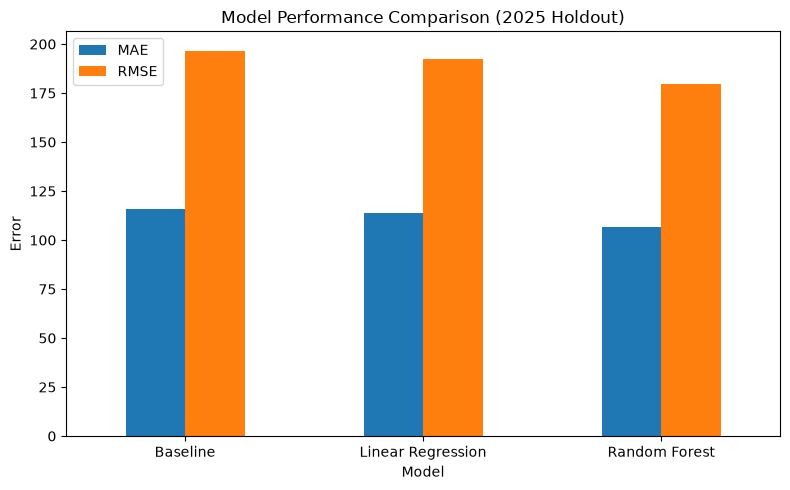

In [9]:
comparison.set_index("Model")[["MAE", "RMSE"]].plot(kind="bar", figsize=(8, 5))
plt.title("Model Performance Comparison (2025 Holdout)")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Random Forest Feature Importance

상관되거나 중복된 feature 사이에서는 importance가 분산될 수 있습니다. 특히 `moveIn`, `moveOut`, `netMove`는 서로 수학적으로 연결되어 있으므로 값을 **인과효과로 해석하지 않습니다.**


In [10]:
rf_importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)
rf_importance


,feature,importance
0,contractCount,0.677166
5,avgLivingPop,0.255037
1,moveIn,0.018481
2,moveOut,0.017999
3,netMove,0.016212
6,month,0.013610
4,baseRate,0.001495


## 9. 실제값과 예측값 확인

2025년 테스트 구간에서 Random Forest의 실제값과 예측값을 비교합니다.


In [11]:
result = test[["guName", "yearMonth"]].copy()
result["actual"] = y_test.to_numpy()
result["predicted"] = rf_pred
result["error"] = result["actual"] - result["predicted"]
result.head(10)


,guName,yearMonth,actual,predicted,error
24,강남구,2025-01-01,2344.0,2264.695,79.305
25,강남구,2025-02-01,2120.0,2457.440,-337.440
26,강남구,2025-03-01,1988.0,1992.135,-4.135
27,강남구,2025-04-01,2236.0,2227.300,8.700
28,강남구,2025-05-01,2028.0,2532.125,-504.125
29,강남구,2025-06-01,1969.0,2049.150,-80.150
30,강남구,2025-07-01,1978.0,2001.225,-23.225
31,강남구,2025-08-01,2000.0,1812.685,187.315
32,강남구,2025-09-01,2071.0,2135.955,-64.955
33,강남구,2025-10-01,2732.0,2204.720,527.280


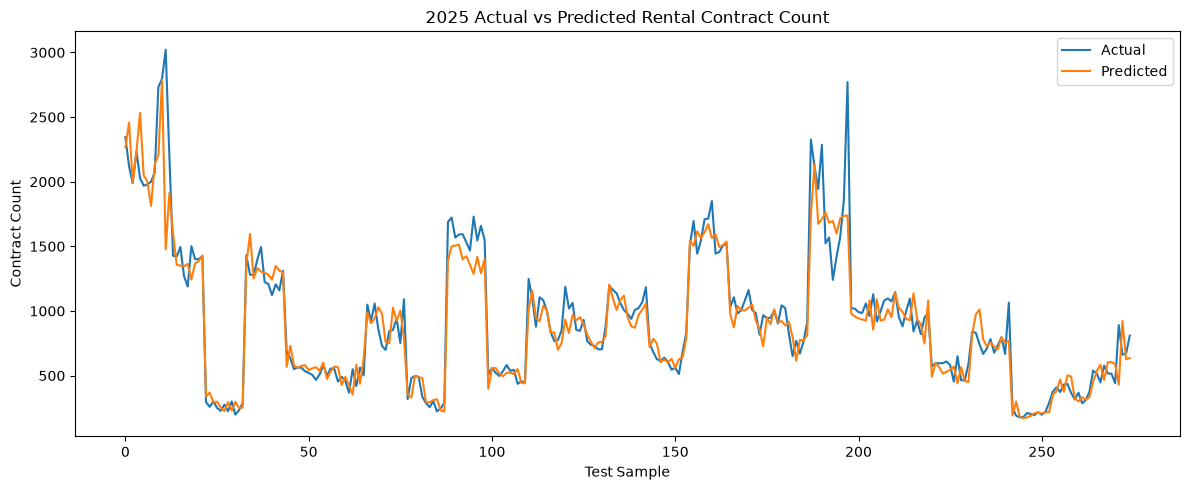

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(range(len(result)), result["actual"], label="Actual")
plt.plot(range(len(result)), result["predicted"], label="Predicted")
plt.xlabel("Test Sample")
plt.ylabel("Contract Count")
plt.title("2025 Actual vs Predicted Rental Contract Count")
plt.legend()
plt.tight_layout()
plt.show()


## 10. 해석 시 주의사항

- target은 **공실/빈방 수가 아니라 다음 달 임대차 계약 건수**입니다.
- `contractCount`는 직전 월 시장 상태를 직접 나타내므로 강한 예측 feature가 될 수 있습니다.
- Feature importance와 회귀계수는 **인과관계의 증거가 아닙니다.**
- 현재 월 인구이동·생활인구 등을 다음 달 예측에 쓰므로 실제 서비스에서는 해당 월 데이터의 발표 시점을 확인해야 합니다.
- 향후에는 lag/rolling feature, 자치구 one-hot, 더 긴 기간의 데이터를 추가해 검증할 수 있습니다.


## 11. 최종 모델 재학습 및 2026년 1월 예측

앞 단계에서는 모델의 성능을 객관적으로 확인하기 위해 **2023~2024년 데이터를 학습하고 2025년 데이터로 검증**했습니다.

검증 후 최종 예측에서는 사용 가능한 데이터를 최대한 활용하기 위해 **2023~2025년의 학습 가능한 전체 데이터**로 Random Forest 모델을 다시 학습합니다.

이후 2025년 12월의 시장 데이터를 입력하여 **2026년 1월 서울 25개 자치구의 임대차 계약 건수**를 예측합니다.

### 최종 예측 과정

1. 2023-01 ~ 2025-11 데이터로 최종 모델 재학습
2. 2025년 12월 데이터를 예측 입력값으로 사용
3. 2026년 1월 자치구별 계약 건수 예측
4. 예측 결과를 MySQL `rent_forecast_2026_01` 테이블에 저장

> 2025년 12월은 다음 달 실제값인 2026년 1월 계약 건수가 데이터에 존재하지 않아 학습용 target을 만들 수 없습니다. 따라서 최종 모델 학습에서는 제외되고 2026년 1월 예측 입력값으로 사용합니다.


In [13]:
# 2023~2025 전체 데이터로 최종 모델 재학습

final_train = model_df.copy()

X_final = final_train[features]
y_final = final_train["nextContractCount"]

final_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_final, y_final)

print("최종 모델 학습 완료")
print("학습 기간:", final_train["yearMonth"].min(), "~", final_train["yearMonth"].max())
print("학습 데이터 수:", len(final_train))

최종 모델 학습 완료
학습 기간: 2023-01-01 00:00:00 ~ 2025-11-01 00:00:00
학습 데이터 수: 875


In [14]:
# 2025년 12월 데이터 → 2026년 1월 거래량 예측

dec_2025 = df[
    df["yearMonth"] == pd.Timestamp("2025-12-01")
].copy()

X_2026_01 = dec_2025[features]

dec_2025["predictedContractCount_2026_01"] = (
    final_model.predict(X_2026_01).round().astype(int)
)

prediction_2026_01 = dec_2025[
    [
        "guName",
        "contractCount",
        "predictedContractCount_2026_01"
    ]
].copy()

prediction_2026_01 = prediction_2026_01.sort_values(
    "predictedContractCount_2026_01",
    ascending=False
)

print("예측 자치구 수:", len(prediction_2026_01))

prediction_2026_01

예측 자치구 수: 25


,guName,contractCount,predictedContractCount_2026_01
35,강남구,2798,2685
647,송파구,2770,2257
323,노원구,1549,1566
539,서초구,1520,1488
71,강동구,1425,1401
143,강서구,1311,1326
467,마포구,1184,1195
683,양천구,1097,1104
251,구로구,1091,1084
503,서대문구,829,1062


In [15]:
# 2026년 1월 예측 결과 MySQL 저장

prediction_2026_01["forecastMonth"] = "2026-01"

prediction_2026_01.to_sql(
    "rent_forecast_2026_01",
    engine,
    if_exists="replace",
    index=False
)

print("MySQL 저장 완료:", len(prediction_2026_01))

MySQL 저장 완료: 25
